# EDA: Superstore Sales Analysis

## Цель

Провести разведочный анализ данных (EDA) для датасета Superstore.  
Понять структуру данных, выявить закономерности, аномалии и ключевые инсайты, которые помогут бизнесу принимать решения.

## Данные

- **Файл:** `data/processed/superstore_clean.csv`
- **Строк:** 9789
- **Колонок:** 24
- **Период:** 2015–2018
- **Регионы:** West, East, Central, South
- **Категории:** Furniture, Office Supplies, Technology
- **Сегменты:** Consumer, Corporate, Home Office

## План анализа

1. Описательная статистика: числовые и категориальные переменные.
2. Выбросы: поиск и решение.
3. Визуализация:
   - Распределения (Sales, Shipping Days).
   - Сравнение групп (Category, Region, Segment).
   - Тренды (годы, месяцы, дни недели).
   - Связи (корреляционная матрица).
4. Выводы: ключевые инсайты для бизнеса.

## Ожидаемые результаты

- Понимание распределения продаж.
- Выявление самых прибыльных категорий, регионов и сегментов.
- Обнаружение сезонности и трендов.
- Формулировка гипотез для статистической проверки.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [4]:
df = pd.read_csv('../data/processed/superstore_clean.csv', parse_dates=['Order Date', 'Ship Date'])
os.makedirs('../reports/figures', exist_ok=True)
print(df.head())
print(df.info())

   Row ID        Order ID Order Date  Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156 2017-11-08 2017-11-11    Second Class    CG-12520   
1       2  CA-2017-152156 2017-11-08 2017-11-11    Second Class    CG-12520   
2       3  CA-2017-138688 2017-06-12 2017-06-16    Second Class    DV-13045   
3       4  US-2016-108966 2016-10-11 2016-10-18  Standard Class    SO-20335   
4       5  US-2016-108966 2016-10-11 2016-10-18  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

          Category  Sub-Category  \
0        Furniture     Bookcases   
1        Furniture        Chairs

In [5]:
print('Sales:')
print(df['Sales'].describe())
print('Медиана Sales: ', df['Sales'].median())
print( 'IQR Sales:', df['Sales'].quantile(0.75) - df['Sales'].quantile(0.25))

print('Shipping Days:')
print(df['Shipping Days'].describe())
print('Медиана Shipping Days: ', df['Shipping Days'].median())
print( 'IQR Shipping Days:', df['Shipping Days'].quantile(0.75) - df['Shipping Days'].quantile(0.25))


Sales:
count     9789.000000
mean       230.116193
std        625.302079
min          0.444000
25%         17.248000
50%         54.384000
75%        210.392000
max      22638.480000
Name: Sales, dtype: float64
Медиана Sales:  54.384
IQR Sales: 193.144
Shipping Days:
count    9789.000000
mean        3.961181
std         1.750452
min         0.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         7.000000
Name: Shipping Days, dtype: float64
Медиана Shipping Days:  4.0
IQR Shipping Days: 2.0


In [6]:
for col in ['Category', 'Sub-Category', 'Region', 'Segment', 'Ship Mode']:
    print(f'{col}:')
    print(df[col].value_counts())
    print(f'Уникальных: {df[col].nunique()}')


Category:
Category
Office Supplies    5903
Furniture          2076
Technology         1810
Name: count, dtype: int64
Уникальных: 3
Sub-Category:
Sub-Category
Binders        1492
Paper          1336
Furnishings     931
Phones          875
Storage         831
Art             784
Accessories     754
Chairs          606
Appliances      458
Labels          357
Tables          314
Envelopes       247
Bookcases       225
Fasteners       214
Supplies        184
Machines        115
Copiers          66
Name: count, dtype: int64
Уникальных: 17
Region:
Region
West       3140
East       2774
Central    2277
South      1598
Name: count, dtype: int64
Уникальных: 4
Segment:
Segment
Consumer       5096
Corporate      2948
Home Office    1745
Name: count, dtype: int64
Уникальных: 3
Ship Mode:
Ship Mode
Standard Class    5849
Second Class      1901
First Class       1501
Same Day           538
Name: count, dtype: int64
Уникальных: 4


In [7]:
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)

IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[(df['Sales'] < lower) | (df['Sales'] > upper)]
print(f'Выбросов в Sales: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)')
print(f'Границы: {lower:.2f} - {upper:.2f}')

Выбросов в Sales: 1141 (11.7%)
Границы: -272.47 - 500.11


In [8]:
print(df.groupby('Category')['Sales'].sum().sort_values(ascending=False))
print(df.groupby('Category')['Sales'].mean().sort_values(ascending=False))

Category
Technology         825856.1130
Furniture          723538.4757
Office Supplies    703212.8240
Name: Sales, dtype: float64
Category
Technology         456.274096
Furniture          348.525277
Office Supplies    119.128041
Name: Sales, dtype: float64


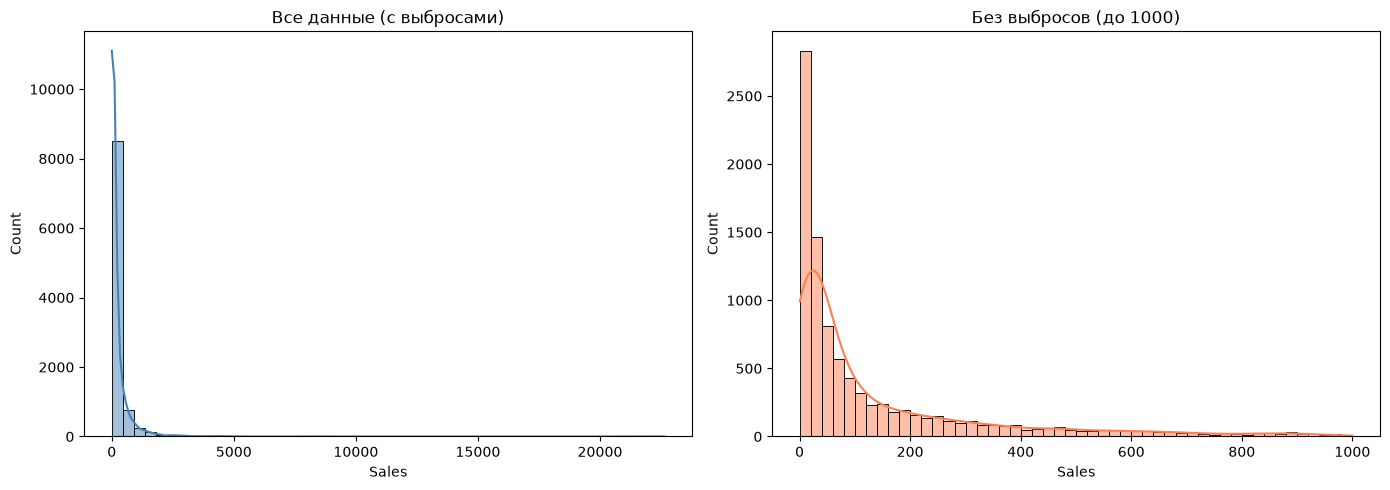

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x='Sales', bins=50, kde=True, color='steelblue', ax=axes[0])
axes[0].set_title('Все данные (с выбросами)')
axes[0].set_xlabel('Sales')

sns.histplot(data=df[df['Sales'] <= 1000], x='Sales', bins=50, kde=True, color='coral', ax=axes[1])
axes[1].set_title('Без выбросов (до 1000)')
axes[1].set_xlabel('Sales')

plt.tight_layout()
plt.savefig('../reports/figures/01_sales_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

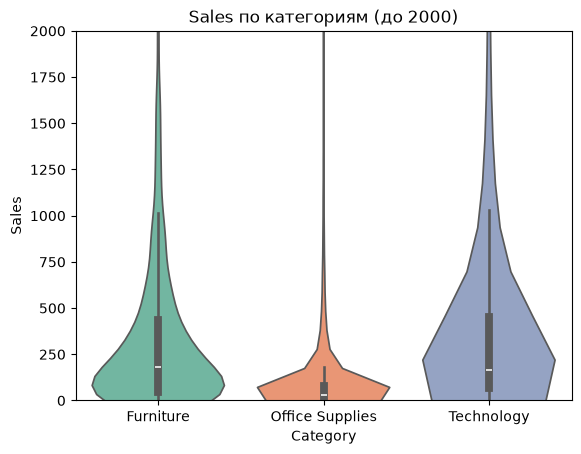

In [11]:
sns.violinplot(data=df, x='Category', y='Sales', hue='Category', palette='Set2', legend=False)
plt.ylim(0, 2000)
plt.title('Sales по категориям (до 2000)')
plt.savefig('../reports/figures/02_sales_category.png', dpi=100, bbox_inches='tight')
plt.show()

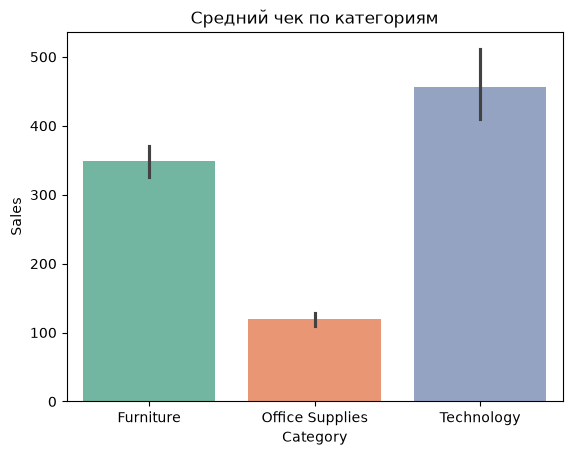

In [12]:
sns.barplot(data=df, x='Category', y='Sales', estimator='mean', hue='Category', palette='Set2', legend=False)
plt.title('Средний чек по категориям')
plt.savefig('../reports/figures/03_mean_sales_category.png', dpi=100, bbox_inches='tight')
plt.show()

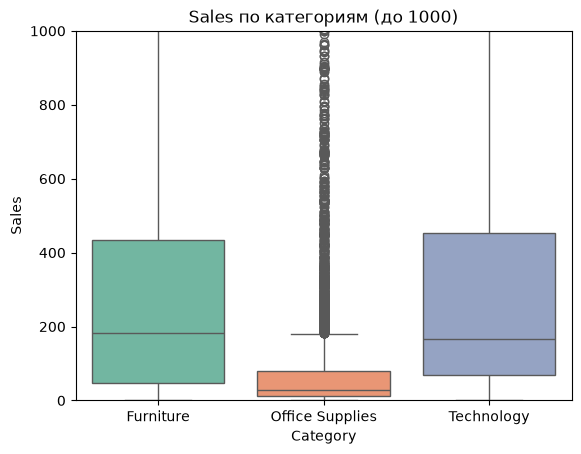

In [13]:
sns.boxplot(data=df, x='Category', y='Sales', hue='Category', palette='Set2', legend=False)
plt.ylim(0, 1000)
plt.title('Sales по категориям (до 1000)')
plt.savefig('../reports/figures/04_sales_distribution_category.png', dpi=100, bbox_inches='tight')
plt.show()

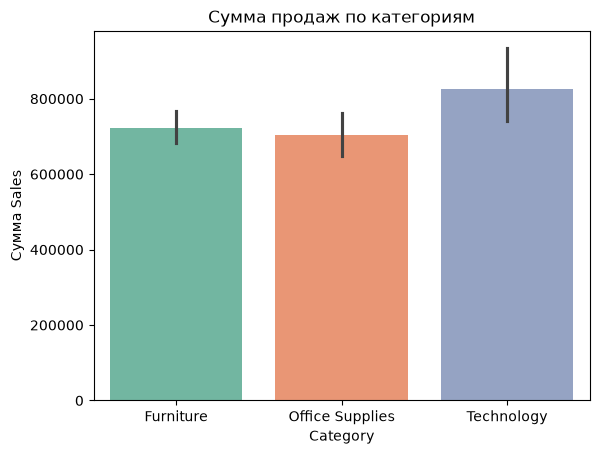

In [14]:
sns.barplot(data=df, x = 'Category', y = 'Sales', estimator = 'sum', hue = 'Category', palette='Set2', legend = False)
plt.title('Сумма продаж по категориям')
plt.ylabel('Сумма Sales')
plt.savefig('../reports/figures/05_sum_sales_category.png', dpi=100, bbox_inches='tight')
plt.show()

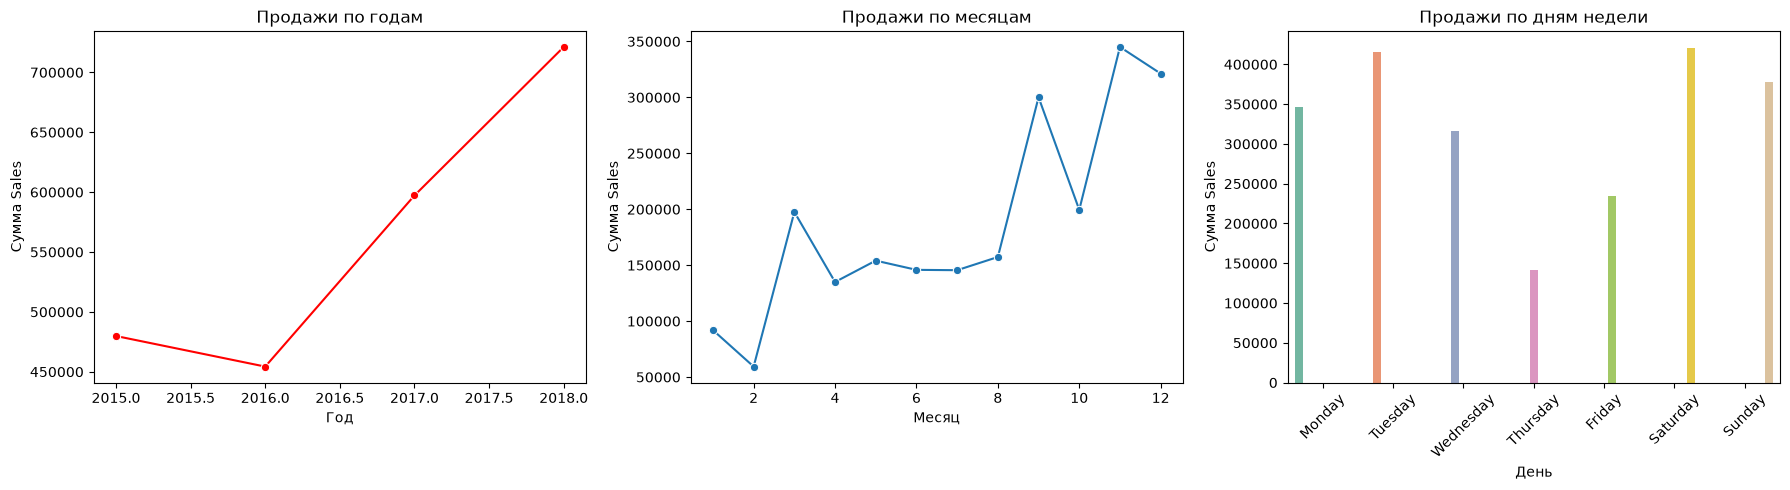

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
yearly = df.groupby('Order Year')['Sales'].sum().reset_index()
sns.lineplot(data=yearly, x = 'Order Year', y = 'Sales', marker = 'o', color = 'red', ax=axes[0])
axes[0].set_title('Продажи по годам')
axes[0].set_ylabel('Сумма Sales')
axes[0].set_xlabel('Год')

yearly = df.groupby('Order Month')['Sales'].sum().reset_index()
sns.lineplot(data=yearly, x = 'Order Month', y = 'Sales', marker = 'o', ax=axes[1])
axes[1].set_title('Продажи по месяцам')
axes[1].set_ylabel('Сумма Sales')
axes[1].set_xlabel('Месяц')

daily = df.groupby('Order Day of Week')['Sales'].sum().reset_index()
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily['Order Day of Week'] = pd.Categorical(daily['Order Day of Week'], categories = order, ordered=True)
daily = daily.sort_values('Order Day of Week')
sns.barplot(data=daily, x='Order Day of Week', y='Sales', hue='Order Day of Week', palette='Set2', legend=False, ax=axes[2])
axes[2].set_title('Продажи по дням недели')
axes[2].set_ylabel('Сумма Sales')
axes[2].set_xlabel('День')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../reports/figures/06_sales_years_months_days.png', dpi=100, bbox_inches='tight')
plt.show()

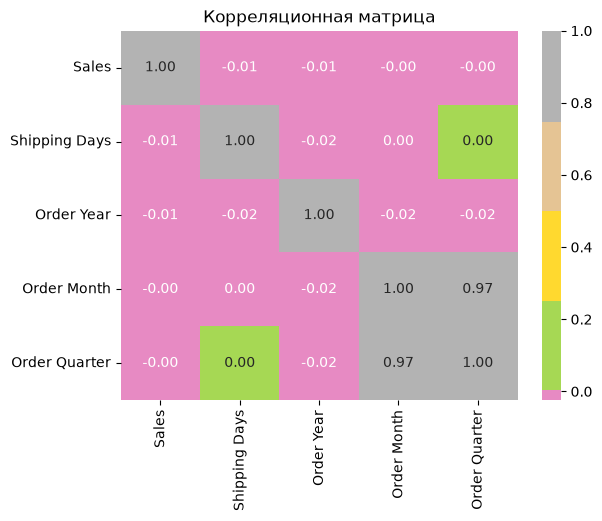

In [ ]:
numeric_cols = ['Sales', 'Shipping Days', 'Order Year', 'Order Month', 'Order Quarter']
corr = df[numeric_cols].corr()

sns.heatmap(corr, annot=True, cmap='virgin', fmt='.2f', center=0)
plt.title('Корреляционная матрица')
plt.savefig('../reports/figures/07_sales_corr.png', dpi=100, bbox_inches='tight')
plt.show()

C:\Users\Acer\AppData\Local\Temp\ipykernel_17492\1757294937.py:1: UserWarning: 
The palette list has fewer values (3) than needed (4) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(data=df, x='Ship Mode', y='Shipping Days', hue='Ship Mode', palette=cmap, legend=False)


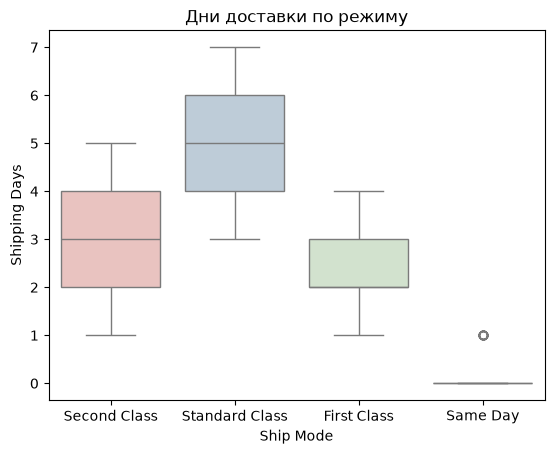

In [53]:
sns.boxplot(data=df, x='Ship Mode', y='Shipping Days', hue='Ship Mode', palette=cmap, legend=False)
plt.title('Дни доставки по режиму')
plt.savefig('../reports/figures/08_ship.png', dpi=100, bbox_inches='tight')
plt.show()

In [63]:
yearly_stats = df.groupby('Order Year').agg(
    total_sales=('Sales', 'sum'),
    order_count=('Order ID', 'nunique'),
    avg_check=('Sales', 'mean')
).reset_index()
print(yearly_stats)

   Order Year  total_sales  order_count   avg_check
0        2015  479856.2081          947  245.702103
1        2016  454315.9054         1017  221.293670
2        2017  597225.4900         1293  236.057506
3        2018  721209.8092         1659  221.706059


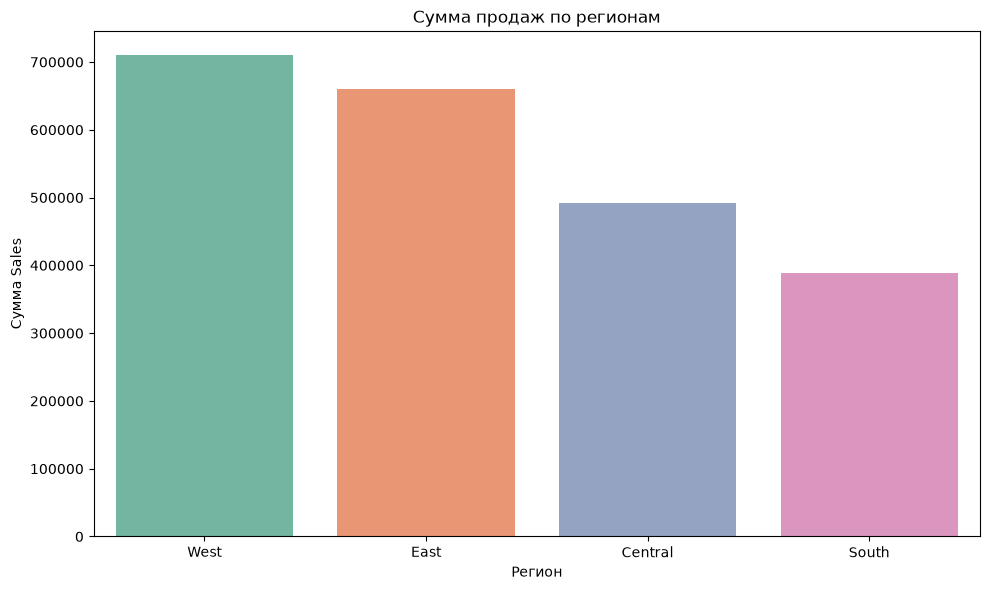

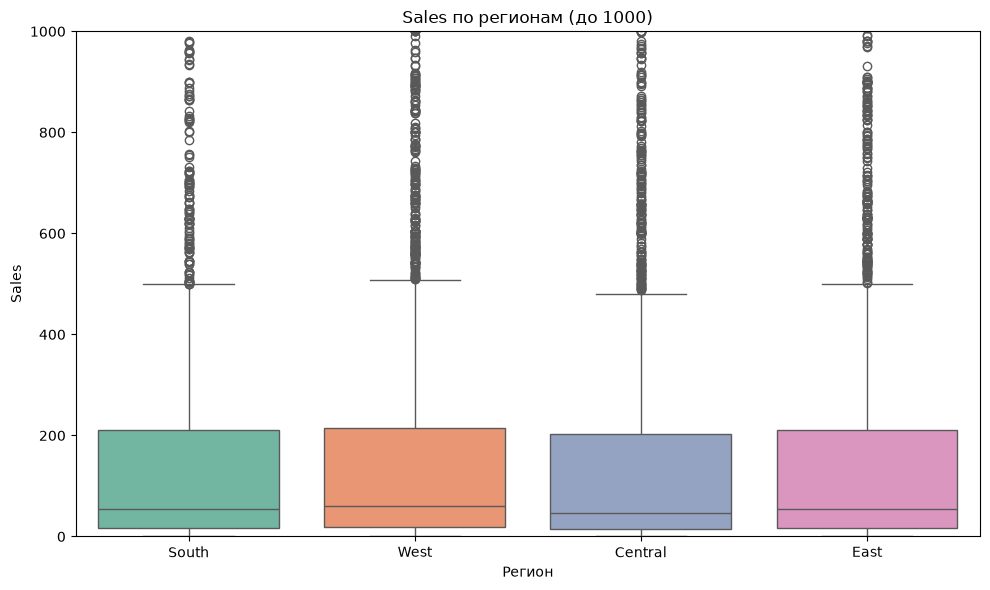

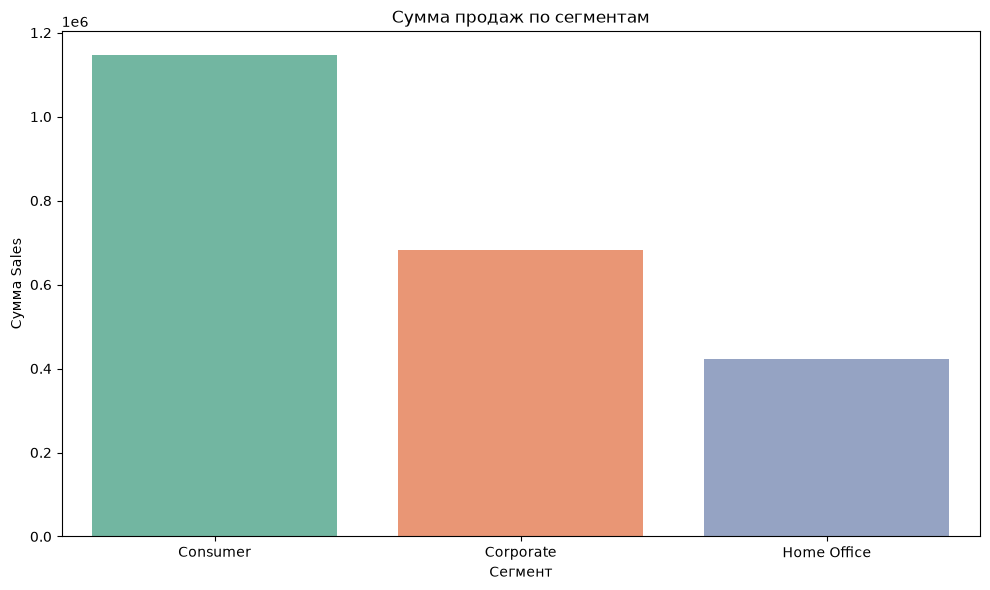

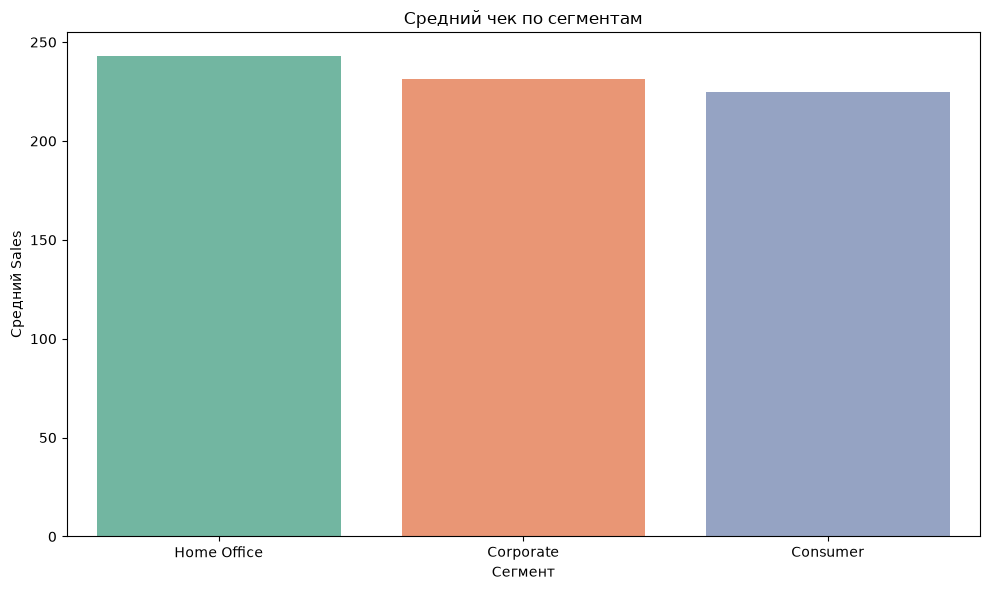

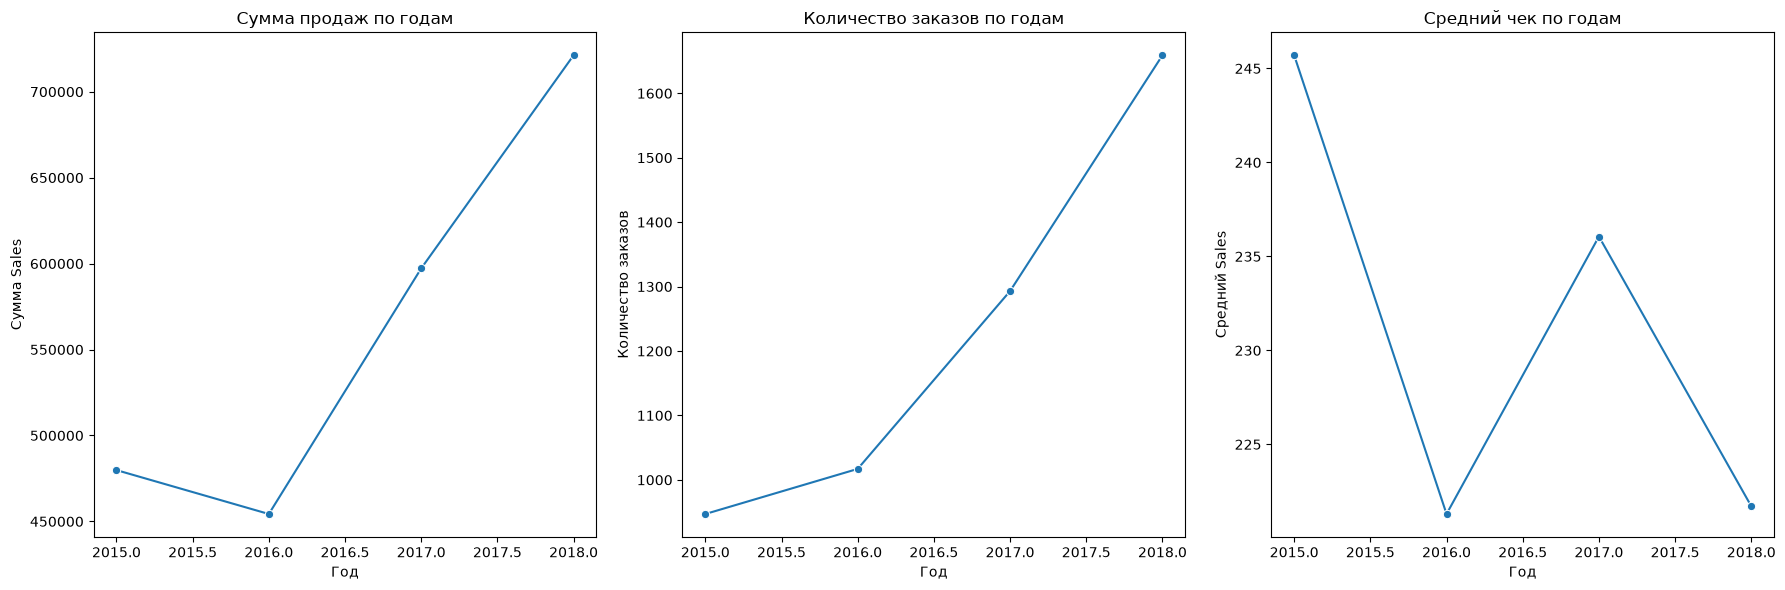

In [64]:
plt.figure(figsize=(10, 6))
region_sales = df.groupby('Region')['Sales'].sum().reset_index().sort_values('Sales', ascending=False)
sns.barplot(data=region_sales, x='Region', y='Sales', hue='Region', palette='Set2', legend=False)
plt.title('Сумма продаж по регионам')
plt.xlabel('Регион')
plt.ylabel('Сумма Sales')
plt.tight_layout()
plt.savefig('../reports/figures/09_sales_by_region.png', dpi=100, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Region', y='Sales', hue='Region', palette='Set2', legend=False)
plt.ylim(0, 1000)
plt.title('Sales по регионам (до 1000)')
plt.xlabel('Регион')
plt.ylabel('Sales')
plt.tight_layout()
plt.savefig('../reports/figures/10_sales_box_by_region.png', dpi=100, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 6))
segment_sales = df.groupby('Segment')['Sales'].sum().reset_index().sort_values('Sales', ascending=False)
sns.barplot(data=segment_sales, x='Segment', y='Sales', hue='Segment', palette='Set2', legend=False)
plt.title('Сумма продаж по сегментам')
plt.xlabel('Сегмент')
plt.ylabel('Сумма Sales')
plt.tight_layout()
plt.savefig('../reports/figures/11_sales_by_segment.png', dpi=100, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 6))
segment_avg = df.groupby('Segment')['Sales'].mean().reset_index().sort_values('Sales', ascending=False)
sns.barplot(data=segment_avg, x='Segment', y='Sales', hue='Segment', palette='Set2', legend=False)
plt.title('Средний чек по сегментам')
plt.xlabel('Сегмент')
plt.ylabel('Средний Sales')
plt.tight_layout()
plt.savefig('../reports/figures/12_avg_check_by_segment.png', dpi=100, bbox_inches='tight')
plt.show()

yearly = df.groupby('Order Year').agg(
    total_sales=('Sales', 'sum'),
    order_count=('Order ID', 'nunique'),
    avg_check=('Sales', 'mean')
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.lineplot(data=yearly, x='Order Year', y='total_sales', marker='o', ax=axes[0])
axes[0].set_title('Сумма продаж по годам')
axes[0].set_xlabel('Год')
axes[0].set_ylabel('Сумма Sales')

sns.lineplot(data=yearly, x='Order Year', y='order_count', marker='o', ax=axes[1])
axes[1].set_title('Количество заказов по годам')
axes[1].set_xlabel('Год')
axes[1].set_ylabel('Количество заказов')

sns.lineplot(data=yearly, x='Order Year', y='avg_check', marker='o', ax=axes[2])
axes[2].set_title('Средний чек по годам')
axes[2].set_xlabel('Год')
axes[2].set_ylabel('Средний Sales')

plt.tight_layout()
plt.savefig('../reports/figures/13_growth_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

## Выводы по EDA

1. Sales имеет сильную правостороннюю асимметрию: медиана 54, среднее 230. Большинство заказов - мелкие, но есть крупные оптовые заказы.

2. Technology - лидер по сумме продаж (825 856) и по среднему чеку (456). Office Supplies - лидер по количеству заказов (5903), но средний чек самый низкий (119).

3. Продажи растут с 2015 по 2018. Рост обеспечивается увеличением количества заказов, а не ростом среднего чека. Средний чек колеблется в диапазоне 220–245.

4. Пик продаж - ноябрь-декабрь. Сезонность выражена: в конце года продажи резко возрастают.

5. Вторник и суббота - самые прибыльные дни недели.

6. Регион West - лидер по сумме продаж (710 000). Регион South - самый слабый (390 000). При этом медианы чеков по регионам почти одинаковы: различия обусловлены количеством крупных заказов.

7. Сегмент Consumer - лидер по сумме продаж (1 150 000). Home Office - аутсайдер (430 000). Но средний чек самый высокий именно у Home Office (245), а самый низкий - у Consumer (225).

8. Standard Class - самый долгий режим доставки (3–7 дней). Same Day - мгновенный (0 дней).

9. Sales не коррелирует с другими переменными (r ≈ 0). Это независимая метрика.